In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st 
import seaborn as sns
g_s = pd.read_csv("gender_submission.csv")
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [2]:
print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
print(test.head())

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  


In [ ]:
# We notice that the "head" of the test set is missing the Survived column (0,1). Our objective will be to predict these values based on the data we already know (the training set).

In [ ]:
# Exploring the training data:

In [6]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [7]:
print(train.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [ ]:
# Count how many NA values each column in "train" has

In [9]:
print(train.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
Q1 = train['Age'].quantile(0.25)
Q3 = train['Age'].quantile(0.75)
IQR = Q3 -Q1
lim_inf = Q1 - 1.5*IQR
lim_sup = Q3 + 1.5*IQR

outliers = train[(train['Age']<lim_inf)|(train['Age']>lim_sup)]
num= len(outliers)
num



11

In [11]:
print(f"Tiene {num} outliers")

Tiene 11 outliers


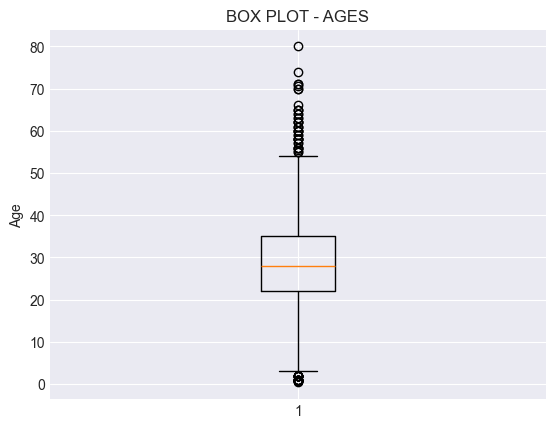

In [37]:
plt.boxplot(train["Age"].dropna())
plt.ylabel("Age")
plt.title("BOX PLOT - AGES")
plt.show() 

In [13]:
sesgo_Age = st.skew(train['Age'].dropna())
print(f"Sesgo: {sesgo_Age:.3f}")

Sesgo: 0.388


In [ ]:
# Skewness = 0.388 (positive skew / right-tailed), which falls within the range of -0.5 to 0.5.
# This indicates we could use either mean or median. We'll resolve our doubts by visualizing the distribution.

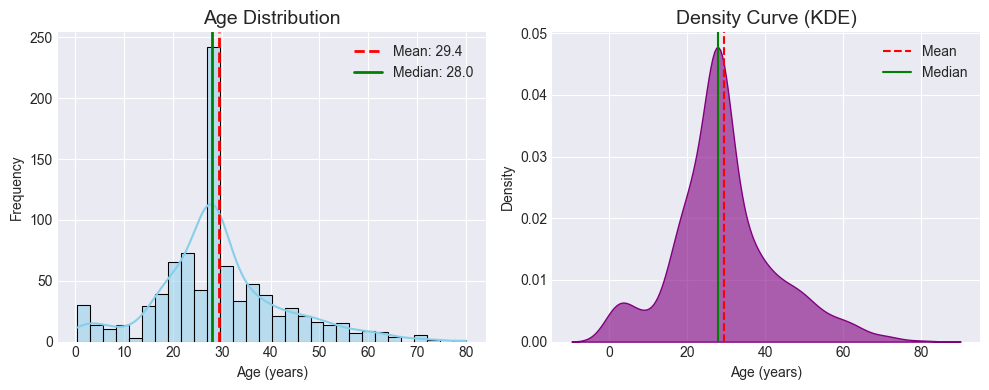

In [38]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram with KDE
ax1 = axes[0]
sns.histplot(train['Age'].dropna(), bins=30, kde=True, ax=ax1, color='skyblue', edgecolor='black')
ax1.axvline(train['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {train['Age'].mean():.1f}")
ax1.axvline(train['Age'].median(), color='green', linestyle='-', linewidth=2, label=f"Median: {train['Age'].median():.1f}")
ax1.set_title('Age Distribution', fontsize=14)
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Frequency')
ax1.legend()

# Density plot (KDE)
ax3 = axes[1]
sns.kdeplot(train['Age'].dropna(), ax=ax3, fill=True, color='purple', alpha=0.6)
ax3.axvline(train['Age'].mean(), color='red', linestyle='--', label='Mean')
ax3.axvline(train['Age'].median(), color='green', linestyle='-', label='Median')
ax3.set_title('Density Curve (KDE)', fontsize=14)
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('Density')
ax3.legend()

plt.tight_layout()
plt.show()

In [ ]:
# We proceed to use the median to fill the NA values in train['Age']

In [ ]:
# Handle missing values:
# - Age: numerical variable, impute with median (or mean)
train['Age'] = train['Age'].fillna(train['Age'].median())  # alternative: .mean()

# - Embarked: categorical variable, impute with mode (most frequent value)
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

In [18]:
train['Cabin2'] = train['Cabin'].str[0]
train['Cabin2']=train['Cabin2'].fillna('UNKNOWN')
train['Cabin2'] 

0      UNKNOWN
1            C
2      UNKNOWN
3            C
4      UNKNOWN
        ...   
886    UNKNOWN
887          B
888    UNKNOWN
889          C
890    UNKNOWN
Name: Cabin2, Length: 891, dtype: object

In [19]:
train['Cabin2'].unique()

array(['UNKNOWN', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [20]:
train['Cabin'] = train['Cabin2']

In [21]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Cabin2         0
dtype: int64

In [22]:
train = train.drop('Cabin2',axis=1)
print(train.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [23]:
train.groupby('Cabin')['Survived'].mean()

Cabin
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
UNKNOWN    0.299854
Name: Survived, dtype: float64

In [ ]:
# Average age of passengers who survived

In [25]:
train.groupby('Survived')['Age'].mean()

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

In [ ]:
# Convert categorical variables to numerical

In [40]:
columns_to_use= ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Cabin']
char_to_num = pd.get_dummies(train[columns_to_use],columns=['Sex','Embarked','Cabin'],drop_first=True)

X=char_to_num
y=train['Survived']

print(f"Final columns used: {X.columns.tolist()}")
print(f"Dimensions: {X.shape}")

Final columns used: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Cabin_B', 'Cabin_C', 'Cabin_D', 'Cabin_E', 'Cabin_F', 'Cabin_G', 'Cabin_T', 'Cabin_UNKNOWN']
Dimensions: (891, 16)


In [41]:
import sklearn as skl
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val= train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Training_Set:{X_train.shape}, Validation_Set:{X_val.shape}")

Training_Set:(712, 16), Validation_Set:(179, 16)


In [42]:
from sklearn.ensemble import RandomForestClassifier
model= RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train,y_train)
print("OK") 

OK


In [44]:
predictions = model.predict(X_val)

In [45]:
predicciones

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1])

In [46]:
from sklearn.metrics import accuracy_score

# Calculate model accuracy on validation set
accuracy = accuracy_score(y_val, predicciones)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.79


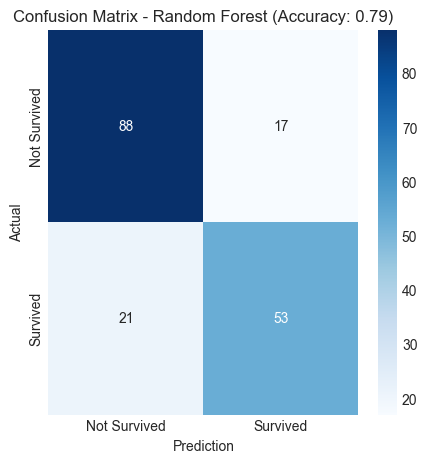

In [49]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_val, predictions)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Random Forest (Accuracy: 0.79)')
plt.show()
